In [1]:
import numpy as np
import pandas as pd
from anndata import AnnData
import scanpy as sc
import multiprocessing as mp
from tqdm import tqdm

Task: map paired single-cell multi-omics cells to spatial locations

# load package

In [2]:
import os
import sys
sys.path.insert(1, '/home/nas3/biod/yangchenghui/proj2/UniG_master/src')
import unig as ug
ug.__version__

/home/yangchenghui/anaconda3/envs/cs_env_new/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'1.1'

In [ ]:
workdir = '/home/nas3/biod/yangchenghui/proj2/proj2_on_ISSAAC/UniG_result/'
ug.settings.set_workdir(workdir)

Saving results in: /home/nas3/biod/yangchenghui/proj2/proj2_on_ISSAAC/UniG_result/


# Data preprocessing

In [4]:
data_path = "/home/nas3/biod/yangchenghui/proj2/conditon_data/ISSAAC/"
sc_RNA_data = sc.read_h5ad(data_path + 'adata_rep1_rna.h5ad')
sc_ATAC_data = sc.read_h5ad(data_path + 'adata_rep1_atac.h5ad')
spatial_RNA_data = sc.read_h5ad(data_path + 'cortex_ST_new.h5ad')
sc_RNA_data, sc_ATAC_data, spatial_RNA_data

(AnnData object with n_obs × n_vars = 2552 × 32285
     obs: 'batch', 'RNA_Cluster', 'Annotation', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
     var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
     uns: 'hvg', 'log1p', 'rank_genes_groups',
 AnnData object with n_obs × n_vars = 2552 × 169148
     obs: 'batch', 'RNA_Cluster', 'Annotation',
 AnnData object with n_obs × n_vars = 1082 × 31053
     obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_Spatial', 'nFeature_Spatial', 'slice', 'region', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'x', 'y'
     var: 'features'
     uns: 'seurat_clusters_colors'
     obsm: 'spatial')

RNA processing

For RNA data, genes with common names across all samples are first selected to ensure consistent identifiers; low‑expression genes are then filtered out, and the remaining expression matrix is normalized to correct for technical variations.

In [ ]:
genes_all_com = list(set(sc_RNA_data.var_names).intersection(set(spatial_RNA_data.var_names)))
print(len(genes_all_com))
sc_RNA_data = sc_RNA_data[:, genes_all_com].copy()
spatial_RNA_data = spatial_RNA_data[:, genes_all_com].copy()

sc_RNA_data = ug.pp.preprocess_rna(sc_RNA_data, normalize=False) #scRNA was normalized already
spatial_RNA_data = ug.pp.preprocess_rna(spatial_RNA_data, n_top_genes = 5000)
sc_RNA_data, spatial_RNA_data

29836


(AnnData object with n_obs × n_vars = 2552 × 18415
     obs: 'batch', 'RNA_Cluster', 'Annotation', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
     var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'n_cells', 'variable'
     uns: 'hvg', 'log1p', 'rank_genes_groups',
 AnnData object with n_obs × n_vars = 1082 × 16468
     obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_Spatial', 'nFeature_Spatial', 'slice', 'region', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'x', 'y'
     var: 'features', 'n_cells', 'moran_I', 'spatial_qval', 'spatially_variable', 'spatially_variable_rank', 'variable'
     uns: 'seurat_clusters_colors', 'log1p', 'spatial_neighbors', 'moranI', 'svg_top_genes'
     obsm: 'spatial'
     obsp: 'spatial_connectivities', 'spatial_distances')

ATAC processing

For ATAC data, peaks are filtered.

In [ ]:
sc_ATAC_data = ug.pp.preprocess_atac(sc_ATAC_data)
peaks_all = list(sc_ATAC_data.var_names)
sc_ATAC_data

AnnData object with n_obs × n_vars = 2552 × 169105
    obs: 'batch', 'RNA_Cluster', 'Annotation'
    var: 'n_cells', 'chr', 'start', 'end'

For each variable gene, select ATAC peaks that fall within the gene body or in its upstream/downstream regions 

In [ ]:
sc_top_genes = sc_RNA_data.var_names[sc_RNA_data.var['highly_variable']].tolist()
spatial_top_genes = spatial_RNA_data.var_names[spatial_RNA_data.var['spatially_variable']].tolist()
genes_selected = list(set(sc_top_genes).intersection(set(spatial_top_genes)))
len(genes_selected)

595

In [ ]:
gene_info = pd.read_csv('/home/nas3/biod/yangchenghui/nas2_ych/FGOT-master/data/P22mousebrain_data/mm10_TSS.txt', sep = '\t')
gene_info = gene_info.rename(columns={'start': 'starts','end': 'ends','Gene': 'genes'})
gene_info.head()

,chr,starts,ends,genes
1,chr1,3466587,3513553,Gm1992
2,chr1,3205901,3671498,Xkr4
3,chr1,3905739,3986215,Gm37381
4,chr1,4292981,4409187,Rp1_2
5,chr1,3999557,4409241,Rp1


In [ ]:
filtered_genes, filtered_peaks, gene_peaks = ug.pp.select_gene_peaks_by_genes_location(gene_info, genes_selected, peaks_all)

Preprocessing gene_info:


27916it [00:00, 106513.33it/s]


Search the genes-peaks correspondence based on gene_info and scope:


27916it [00:24, 1125.55it/s]


Search the filtered peaks:


100%|██████████| 581/581 [00:00<00:00, 307610.53it/s]

There are 581 genes that can be identified from the TSS information.
There are 23830 peaks near the upstream and downstream of the above genes.


In [ ]:
sc_rna_adata_fltr = sc_RNA_data[:,filtered_genes]
spatial_rna_adata_fltr = spatial_RNA_data[:,filtered_genes]
sc_atac_adata_fltr = sc_ATAC_data[:,filtered_peaks]
sc_rna_adata_fltr,spatial_rna_adata_fltr,sc_atac_adata_fltr

sc_rna_adata_fltr.write(workdir + "sc_RNA_adata_fltr.h5ad")
sc_atac_adata_fltr.write(workdir + "sc_ATAC_adata_fltr.h5ad")
spatial_rna_adata_fltr.write(workdir + "spatial_RNA_adata_fltr.h5ad")

/home/yangchenghui/anaconda3/envs/cs_env_new/lib/python3.11/site-packages/anndata/_core/anndata.py:1175: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  df[key] = c


gene-peak relation

In [ ]:
from scipy import sparse
gene_to_idx = {gene: i for i, gene in enumerate(filtered_genes)}
peak_to_idx = {peak: i for i, peak in enumerate(filtered_peaks)}
rows = []
cols = []

filtered_peaks_set = set(filtered_peaks)
for gene in tqdm(filtered_genes):
    if gene in gene_peaks:
        current_peaks = gene_peaks[gene]
        valid_peaks = [p for p in current_peaks if p in peak_to_idx]
        if valid_peaks:
            g_idx = gene_to_idx[gene]
            p_idxs = [peak_to_idx[p] for p in valid_peaks]
            rows.extend([g_idx] * len(p_idxs))
            cols.extend(p_idxs)
data = np.ones(len(rows), dtype=int)
sparse_mat = sparse.coo_matrix((data, (rows, cols)), 
                               shape=(len(filtered_genes), len(filtered_peaks))).tocsr()
adata_GP = sc.AnnData(X=sparse_mat)
adata_GP.obs_names = filtered_genes
adata_GP.var_names = filtered_peaks
adata_GP.write(workdir+"adata_GenePeak_final.h5ad")
adata_GP

100%|██████████| 581/581 [00:06<00:00, 93.90it/s] 


AnnData object with n_obs × n_vars = 581 × 23830

gene expression discretization

/home/nas3/biod/yangchenghui/proj2/UniG_master/src/unig/utils.py:70: ImplicitModificationWarning: Setting element `.layers['unig']` of view, initializing view as actual.
  adata.layers['unig'] = X.copy()
/home/nas3/biod/yangchenghui/proj2/UniG_master/src/unig/utils.py:70: ImplicitModificationWarning: Setting element `.layers['unig']` of view, initializing view as actual.
  adata.layers['unig'] = X.copy()


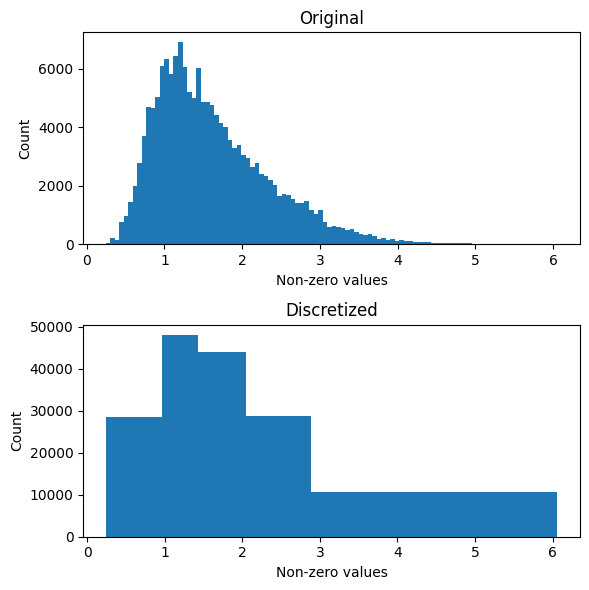

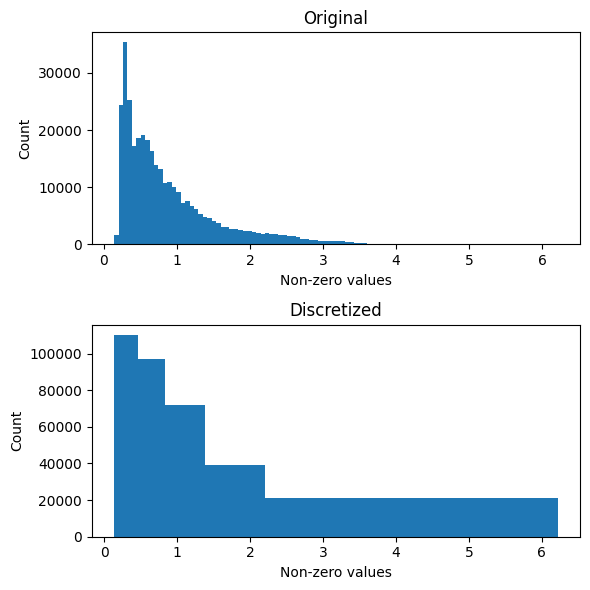

In [ ]:
ug.tl.discretize(sc_rna_adata_fltr,n_bins=5)
ug.pl.discretize(sc_rna_adata_fltr,kde=False)

ug.tl.discretize(spatial_rna_adata_fltr,n_bins=5)
ug.pl.discretize(spatial_rna_adata_fltr,kde=False)

In [ ]:
sc_rna_adata_fltr.write(workdir + "sc_RNA_adata_fltr_final.h5ad")
spatial_rna_adata_fltr.write(workdir + "spatial_RNA_adata_fltr_final.h5ad")

peak accessibility binarization

In [ ]:
ug.pp.binarize(sc_atac_adata_fltr)
sc_atac_adata_fltr.write(workdir+"sc_ATAC_adata_fltr_final.h5ad")

peak-motif relation

In [ ]:
# Pure Python peak x motif scanning with defaults matching the motifmatchr workflow.
# Register the FASTA once per Python process; later scans only need peaks and genome.
ug.pp.register_genome(
    "mm10",
    ("/home/nas3/biod/yangchenghui/proj2/UniG_master/genomes/mm10/mm10.fa"),
)
peak_motif_matrix = ug.pp.peak_motif_matrix(
    sc_atac_adata_fltr.var_names,
    genome="mm10",
    n_jobs=min(8, mp.cpu_count()),
)

adata_PM = AnnData(peak_motif_matrix)
ug.pp.binarize(adata_PM)

adata_PM.write(workdir+"adata_PeakMotif_final.h5ad")
adata_PM

AnnData object with n_obs × n_vars = 23830 × 107

spatial spot-spot relation

In [ ]:
adata_C_spatial = ug.tl.SpaNeighbor(spatial_rna_adata_fltr, k = 10)
adata_C_spatial.write(workdir+"spatial_InnerCell_final.h5ad")
adata_C_spatial

AnnData object with n_obs × n_vars = 1082 × 1082

anchor spot-spot relation

#shared features: 581
Performing randomized SVD ...
Searching for mutual nearest neighbors ...
14846 edges are selected
#selected edges: 14846


AnnData object with n_obs × n_vars = 2552 × 1082
    obs: 'batch', 'RNA_Cluster', 'Annotation', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_Spatial', 'nFeature_Spatial', 'slice', 'region', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'x', 'y'
    obsm: 'svd'
    varm: 'svd'
    layers: 'unig'

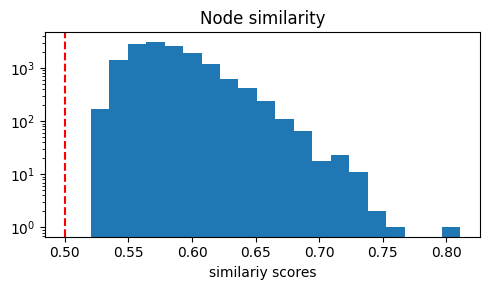

In [ ]:
# MNN between sc RNA spot and spatial RNA spot 
adata_scspatialrna = ug.tl.infer_edges(sc_rna_adata_fltr, spatial_rna_adata_fltr, n_components=15, k=15)
ug.pl.node_similarity(adata_scspatialrna,cutoff=0.5)
adata_scspatialrna.write(workdir+"adata_MNN_final.h5ad")
adata_scspatialrna

# Generate graph

In [ ]:
sc_rna_adata_fltr = sc.read_h5ad(workdir +"sc_RNA_adata_fltr_final.h5ad")
spatial_rna_adata_fltr = sc.read_h5ad(workdir+"spatial_RNA_adata_fltr_final.h5ad")
sc_atac_adata_fltr = sc.read_h5ad(workdir+"sc_ATAC_adata_fltr_final.h5ad")
adata_C_spatial = sc.read_h5ad(workdir+"spatial_InnerCell_final.h5ad")
adata_PM = sc.read_h5ad(workdir+"adata_PeakMotif_final.h5ad")
adata_GP = sc.read_h5ad(workdir+"adata_GenePeak_final.h5ad")
adata_MNN_all = sc.read_h5ad(workdir+"adata_MNN_final.h5ad")

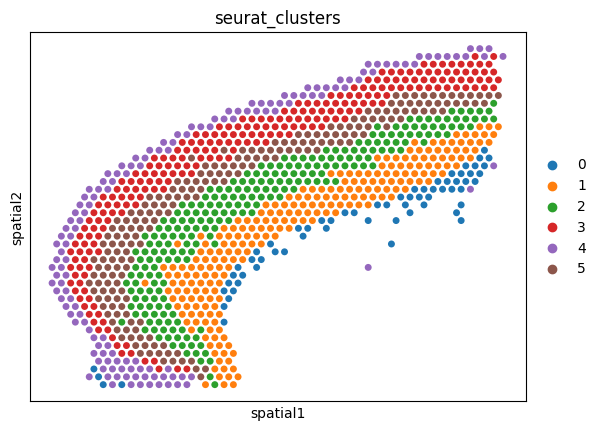

In [ ]:
sc.pl.embedding(spatial_rna_adata_fltr, basis='spatial', color=['seurat_clusters'], size=100)

In [ ]:
ug.gen_graph(list_CP=[sc_atac_adata_fltr],
             list_CG=[sc_rna_adata_fltr,spatial_rna_adata_fltr],
             list_PM=[adata_PM],
             list_CC_Spatial=[adata_C_spatial],
             list_CC_Anchor=[adata_MNN_all],
             list_GP=[adata_GP],
             weight_CP = 3,
             weight_PM = 1,
             weight_CC_Spatial = 5,
             weight_CC_Anchor = 5,
             weight_GP = 1,
             copy=False,
             dirname='graph_0')

`unig` does not exist in anndata 0 in `list_CP`.`.X` is being used instead.
relation0: source: C, destination: P
#edges: 3323456
`unig` does not exist in anndata 0 in `list_PM`.`.X` is being used instead.
relation1: source: P, destination: M
#edges: 299676


/home/nas3/biod/yangchenghui/proj2/UniG_master/src/unig/pbg.py:305: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_edges = pd.concat(


relation2: source: C, destination: G
#edges: 28537
relation3: source: C, destination: G
#edges: 48111
relation4: source: C, destination: G
#edges: 44054
relation5: source: C, destination: G
#edges: 28792
relation6: source: C, destination: G
#edges: 10761
relation7: source: C2, destination: G
#edges: 110191
relation8: source: C2, destination: G
#edges: 97097
relation9: source: C2, destination: G
#edges: 71722
relation10: source: C2, destination: G
#edges: 39413
relation11: source: C2, destination: G
#edges: 20983
`unig` does not exist in anndata 0 in `list_CC_Spatial`.`.X` is being used instead.
relation12 (Spatial): source: C2, destination: C2
#edges: 11636
relation13 (Achor): source: C, destination: C2
#edges: 14846
`unig` does not exist in anndata 0 in `list_GP`.`.X` is being used instead.
relation14: source: G, destination: P
#edges: 26927
Total number of edges: 4176202
Writing graph file "pbg_graph.txt" to "/home/nas3/biod/yangchenghui/proj2/proj2_on_ISSAAC/UniG_result/pbg/graph_0"

# Training

In [ ]:
pbg_training_stages = [
    {
        "name": "stage1_pretrain",
        "output": "model_0",
        "params": {
            "workers": 12,
            "lr": 0.1,
            "num_epochs": 10,
        },
    },
    {
        "name": "stage2_joint_finetune",
        "resume_from_previous": True,
        "params": {
            "workers": 12,
            "lr": 0.01,
            "num_epochs": 20,
            "alpha_ot_rna": 1e4,
            "alpha_ot_atac": 2e4,
            "alpha_triplet": 1000,
            "alpha_ot_gp": 2000,
            "begin_triplet_epoch": 10,
            "triplet_update_freq": 2,
            "rna_aggregation": False
        },
    },
]

pbg_configs = ug.run_training_stages(
    base_params=ug.settings.pbg_params,
    stages=pbg_training_stages,
)

=============== Start stage1_pretrain ===============
Random seeds set to 42 for reproducibility
Auto-estimated weight decay: 8.485019E-03
Training mode: standard
Converting input data...
[2026-08-21 14:36:28.306600] Using the 15 relation types given in the config
[2026-08-21 14:36:28.307063] Searching for the entities in the edge files...
[2026-08-21 14:36:32.293198] Entity type C:
[2026-08-21 14:36:32.294493] - Found 2552 entities
[2026-08-21 14:36:32.294830] - Removing the ones with fewer than 1 occurrences...
[2026-08-21 14:36:32.295408] - Left with 2552 entities
[2026-08-21 14:36:32.295648] - Shuffling them...
[2026-08-21 14:36:32.296722] Entity type C2:
[2026-08-21 14:36:32.296984] - Found 1082 entities
[2026-08-21 14:36:32.297214] - Removing the ones with fewer than 1 occurrences...
[2026-08-21 14:36:32.297538] - Left with 1082 entities
[2026-08-21 14:36:32.297767] - Shuffling them...
[2026-08-21 14:36:32.298309] Entity type G:
[2026-08-21 14:36:32.298547] - Found 581 entities
[

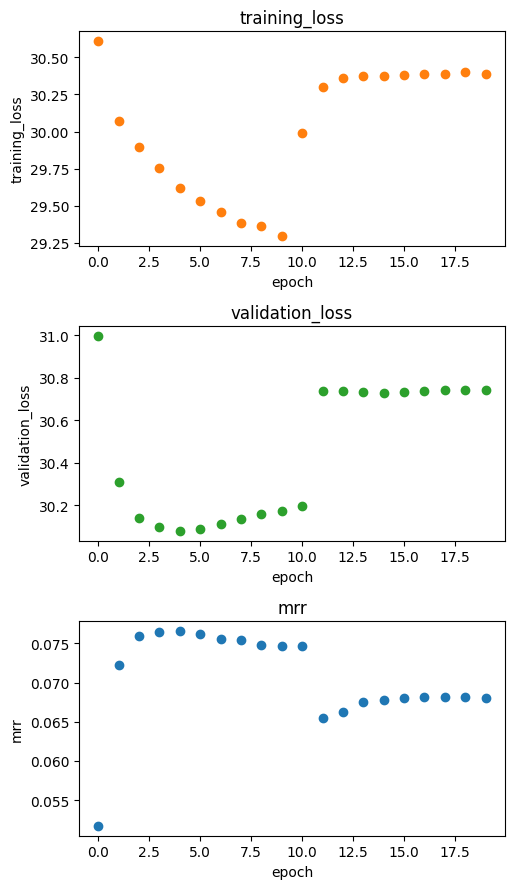

In [ ]:
dict_config_s2 = pbg_configs["stage2_joint_finetune"]
ug.settings.pbg_params = dict_config_s2
ug.pl.pbg_metrics(fig_ncol=1)

# Post-training analysis

In [ ]:
dict_adata = ug.tl.read_embedding()
dict_adata

In [ ]:
adata_C = dict_adata['C']
adata_C2 = dict_adata['C2']
adata_G = dict_adata['G']  # embeddings for genes
adata_P = dict_adata['P']  # embeddings for peaks
adata_M = dict_adata['M']  # embeddings for motifs

adata_M.obs.index = 'M_'+adata_M.obs.index
adata_C.obs["entity_anno"] = "sc_cells"
adata_C2.obs["entity_anno"] = "spots"
adata_G.obs["entity_anno"] = "Gene"
adata_P.obs["entity_anno"] = "Peak"
adata_M.obs["entity_anno"] = "Motif"

adata_C.obs['Ground_Truth'] = sc_rna_adata_fltr[adata_C.obs_names,:].obs['Annotation'].copy()

adata_C2.obs['Ground_Truth'] = spatial_rna_adata_fltr[adata_C2.obs_names,:].obs['seurat_clusters'].copy()
adata_C2.obsm['spatial'] = spatial_rna_adata_fltr[adata_C2.obs_names,:].obsm['spatial'].copy()

In [ ]:
import pickle
adata_dict = {
    'C': adata_C,
    'C2': adata_C2,
    'G': adata_G,
    'P': adata_P,
    'M': adata_M
}

with open(workdir+'ISSAAC_UniG_adata_dict.pkl', 'wb') as f:
    pickle.dump(adata_dict, f)
print(f"Saved AnnData dictionary to {workdir+'ISSAAC_UniG_adata_dict.pkl'}")

Saved AnnData dictionary to /home/nas3/biod/yangchenghui/proj2/proj2_on_ISSAAC/UniG_result/ISSAAC_UniG_adata_dict.pkl


visualize embeddings of cells

fitting ...
  |======================================================================| 100%


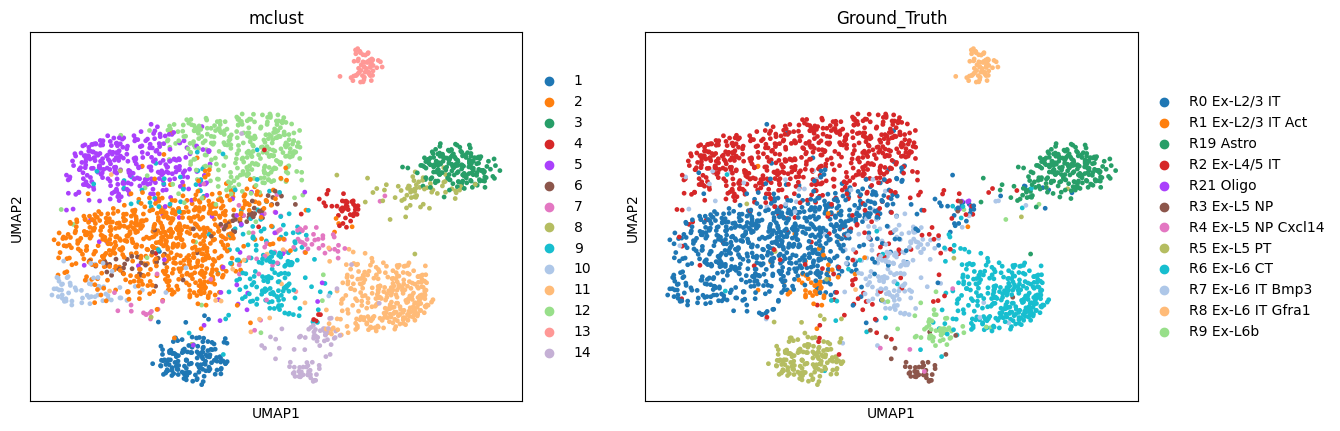

In [ ]:
sc.pp.neighbors(adata_C)
sc.tl.umap(adata_C)
ug.tl.mclust_R(adata_C,14)
sc.pl.umap(adata_C, color=["mclust","Ground_Truth"])

fitting ...
  |======================================================================| 100%


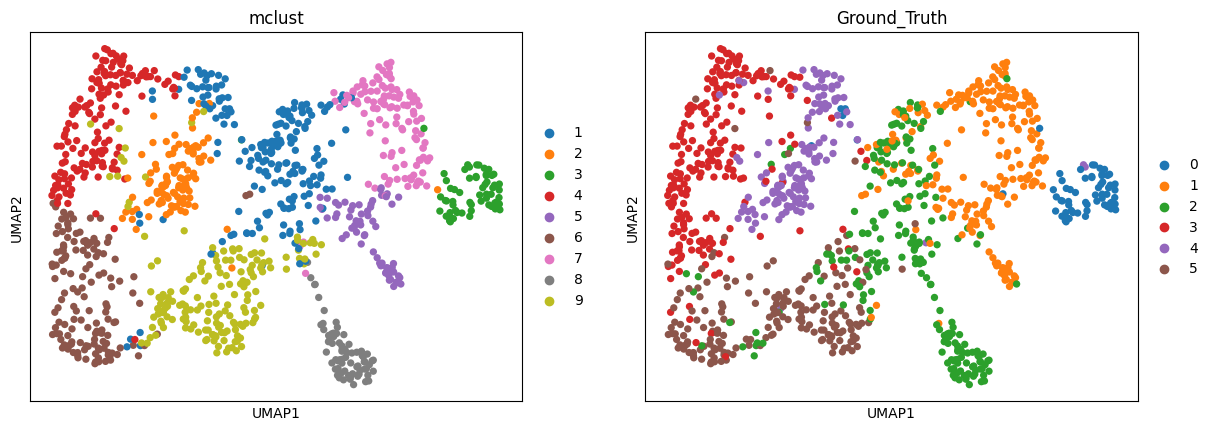

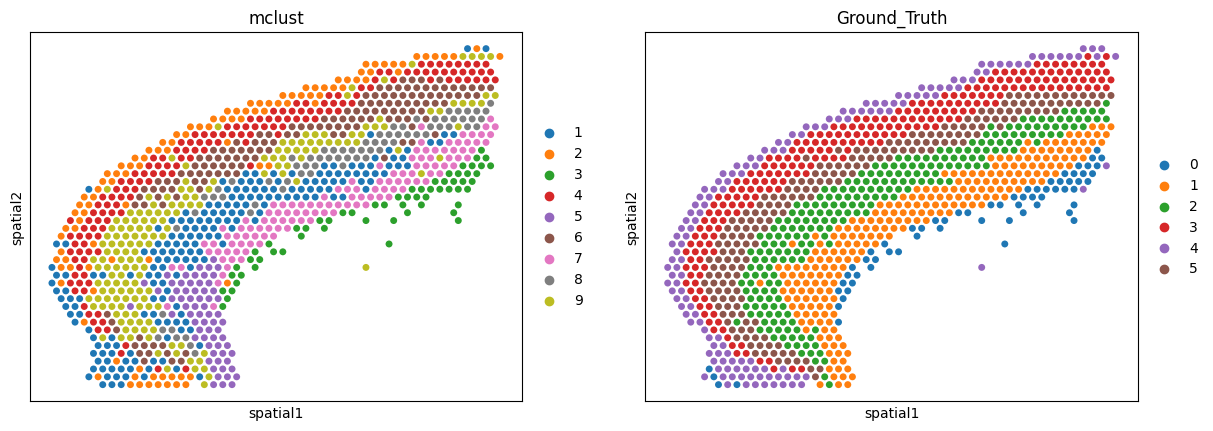

In [ ]:
sc.pp.neighbors(adata_C2)
sc.tl.umap(adata_C2)
ug.tl.mclust_R(adata_C2, 9, modelNames='EII')
sc.pl.umap(adata_C2, color=["mclust","Ground_Truth"])
sc.pl.embedding(adata_C2, basis='spatial', color=["mclust",'Ground_Truth'], size=100)

Integration of the two embedding spaces

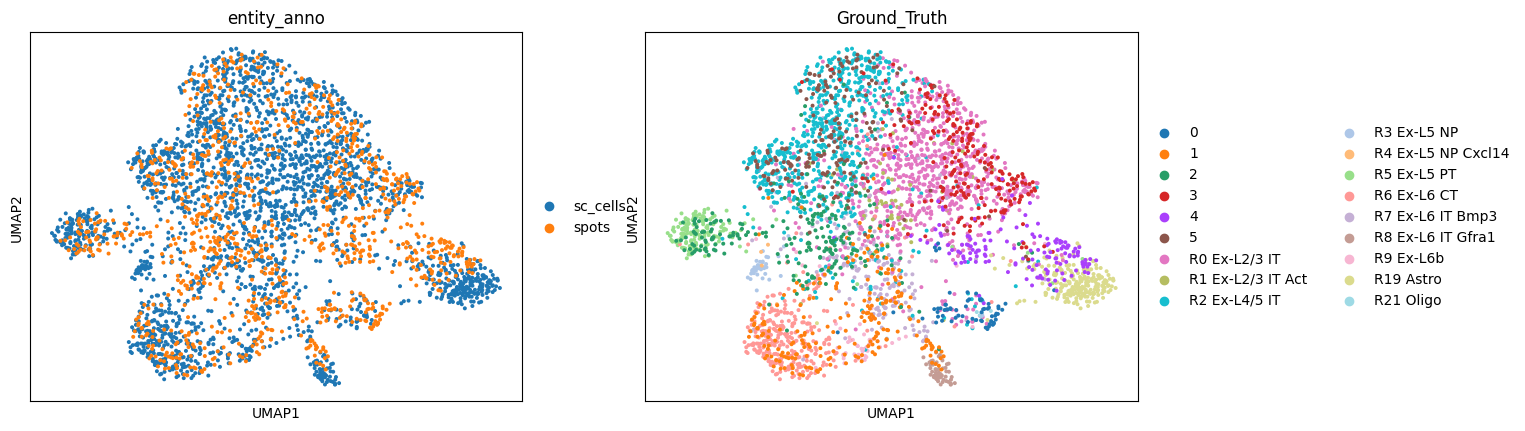

In [ ]:
combined = adata_C.concatenate(adata_C2, join='outer')
print(combined)

sc.pp.neighbors(combined)
sc.tl.umap(combined)
sc.pl.umap(combined, color=["entity_anno", "Ground_Truth"])

# Spatial assignment for single cells

In [9]:
import pickle
file_path = '/home/nas3/biod/yangchenghui/proj2/proj2_on_ISSAAC/UniG_result/ISSAAC_UniG_adata_dict.pkl'
with open(file_path, 'rb') as f:
    dict_adata = pickle.load(f)
adata_C = dict_adata['C']
adata_C2 = dict_adata['C2']
adata_G = dict_adata['G']

In [ ]:
adata_sc_mapped,_,_ = ug.mapping.map_rna_cells(adata_C, adata_C2, adata_G,
                         label = "Ground_Truth", k_cells_per_spot = 5)

Mapping 2552 single cells to 1082 spatial spots.
Step 1: Preparing FGW input matrices.
Step 2: Running Fused Gromov-Wasserstein OT (alpha=0.5).
It.  |Loss        |Relative loss|Absolute loss
------------------------------------------------
    0|2.922365e-01|0.000000e+00|0.000000e+00
    1|2.180486e-01|3.402359e-01|7.418796e-02
    2|2.180480e-01|2.535298e-06|5.528167e-07
    3|2.180480e-01|1.992717e-09|4.345080e-10
Step 3: Estimating spot-level cell type quotas with NNLS.
Step 4: Assigning cells by OT probability and spot quotas.
Step 5: Assigning remaining cells (45 cells).
Assigned 2507 cells.
Step 6: Computing sub-spot coordinates.
Finished mapping. Output contains 2507 cells.


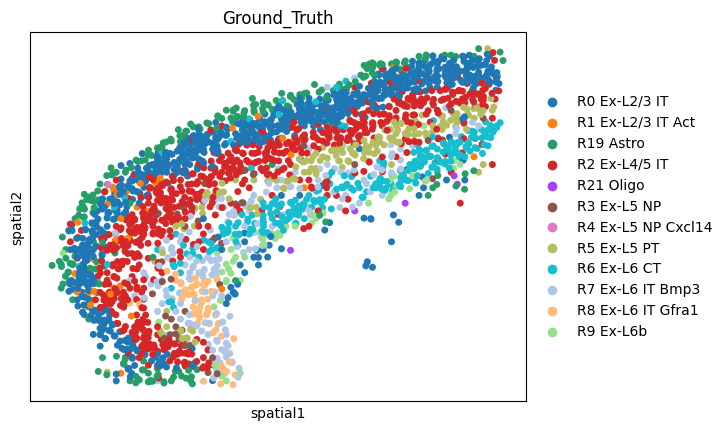

In [6]:
sc.pl.embedding(adata_sc_mapped, basis='spatial', color=['Ground_Truth'], size=100)